# MuJoCo Warp Rendering Demo

This notebook demonstrates the simplest way to render an image using `mujoco_warp`.

## 1. Imports

In [1]:
import mujoco
import numpy as np
import warp as wp
from PIL import Image
import matplotlib.pyplot as plt

import mujoco_warp as mjw

Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `wp.context.Module` will soon be removed from the public API. It can still be accessed from `warp._src.context.Module` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `wp.context.get_module` will soon be removed from the public API. It can still be accessed from `warp._src.context.get_module` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.vec` will soon be removed from the public API. Use `warp.types.vector` instead.
Warp DeprecationWarning: The symbol `warp.mat` will soon be removed from the public API. Use `warp.types.matrix` instead.
Warp DeprecationWarning: The namespace `warp.math` will soon be removed from the public API. It can still be accessed from `warp._src.math` but migh

## 2. Load Model

Load a MuJoCo model from an XML file.

In [2]:
# Load the humanoid model
xml_path = "../benchmark/humanoid/humanoid.xml"
mjm = mujoco.MjModel.from_xml_path(xml_path)

# Create MuJoCo data and run forward kinematics
mjd = mujoco.MjData(mjm)
mujoco.mj_forward(mjm, mjd)

print(f"Model loaded: {mjm.ngeom} geoms, {mjm.ncam} cameras")

Model loaded: 20 geoms, 3 cameras


## 3. Initialize Warp and Put Model/Data on GPU

In [3]:
# Initialize Warp
wp.config.quiet = True
wp.init()

# Put model and data on device
m = mjw.put_model(mjm)
d = mjw.put_data(mjm, mjd, nworld=1)  # Single world

print(f"Model on GPU: ngeom={m.ngeom}, ncam={m.ncam}, nlight={m.nlight}")

Warp DeprecationWarning: The symbol `wp.context.runtime` will soon be removed from the public API. It can still be accessed from `warp._src.context.runtime` but might be changed or removed without notice.
Model on GPU: ngeom=20, ncam=3, nlight=2


## 4. Create Render Context

The render context holds all rendering state and buffers.

In [4]:
# Rendering parameters
width, height = 512, 512
render_rgb = True
render_depth = True
use_textures = True
use_shadows = False

# Create render context
rc = mjw.create_render_context(
    mjm,  # MuJoCo model (CPU)
    m,  # MuJoCo Warp model (GPU)
    d,  # MuJoCo Warp data (GPU)
    (width, height),
    render_rgb,
    render_depth,
    use_textures,
    use_shadows,
    enabled_geom_groups=[0, 1, 2],
)

print(f"Render context created: {width}x{height}")

Render context created: 512x512


## 5. Render Frame

Call `mjw.render()` to render the current frame.

In [5]:
# Render!
mjw.render(m, d, rc)

print("Frame rendered!")

Frame rendered!


In [14]:
d

Data(solver_niter=array(shape=(1,), dtype=int32), ne=array(shape=(1,), dtype=int32), nf=array(shape=(1,), dtype=int32), nl=array(shape=(1,), dtype=int32), nefc=array(shape=(1,), dtype=int32), time=array(shape=(1,), dtype=float32), energy=array(shape=(1,), dtype=vec2f), qpos=array(shape=(1, 28), dtype=float32), qvel=array(shape=(1, 27), dtype=float32), act=array(shape=(1, 0), dtype=float32), qacc_warmstart=array(shape=(1, 27), dtype=float32), ctrl=array(shape=(1, 21), dtype=float32), qfrc_applied=array(shape=(1, 27), dtype=float32), xfrc_applied=array(shape=(1, 17), dtype=vector(length=6, dtype=float32)), eq_active=array(shape=(1, 0), dtype=warp._src.types.bool), mocap_pos=array(shape=(1, 0), dtype=vec3f), mocap_quat=array(shape=(1, 0), dtype=quatf), qacc=array(shape=(1, 27), dtype=float32), act_dot=array(shape=(1, 0), dtype=float32), sensordata=array(shape=(1, 0), dtype=float32), xpos=array(shape=(1, 17), dtype=vec3f), xquat=array(shape=(1, 17), dtype=quatf), xmat=array(shape=(1, 17), 

## 6. Extract and Display RGB Image

The RGB data is stored as packed uint32 values in `rc.rgb_data`.

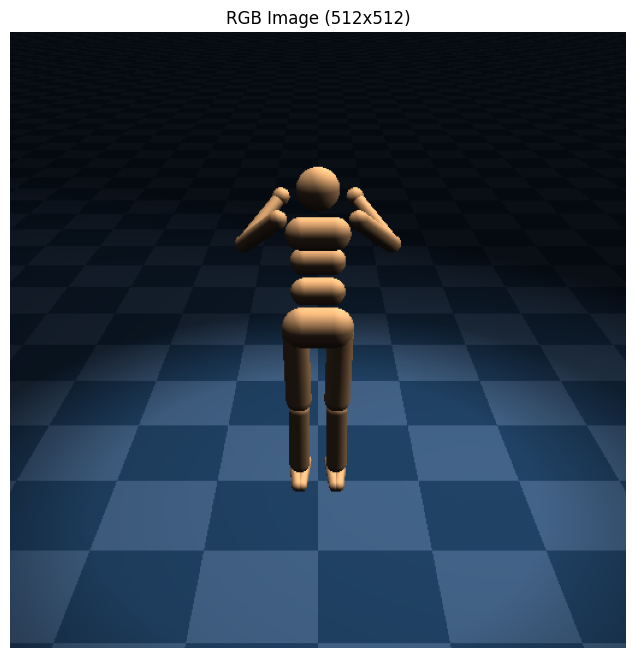

In [6]:
def unpack_rgb(packed_data, width, height):
    """Convert packed uint32 RGB data to (H, W, 3) uint8 array."""
    packed = packed_data.reshape(height, width).astype(np.uint32)
    b = (packed & 0xFF).astype(np.uint8)
    g = ((packed >> 8) & 0xFF).astype(np.uint8)
    r = ((packed >> 16) & 0xFF).astype(np.uint8)
    return np.dstack([r, g, b])


# Get camera info
cam_idx = 0  # Use first camera
world_idx = 0  # Use first world

# Get addresses and resolution
rgb_adr = rc.rgb_adr.numpy()
cam_res = rc.cam_res.numpy()
cam_w, cam_h = int(cam_res[cam_idx][0]), int(cam_res[cam_idx][1])

# Extract RGB for this camera
rgb_data = rc.rgb_data.numpy()
start = rgb_adr[cam_idx]
end = start + cam_w * cam_h
packed_row = rgb_data[world_idx, start:end]

# Unpack and display
rgb_image = unpack_rgb(packed_row, cam_w, cam_h)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_image)
plt.title(f"RGB Image ({cam_w}x{cam_h})")
plt.axis("off")
plt.show()

## 7. Extract and Display Depth Image

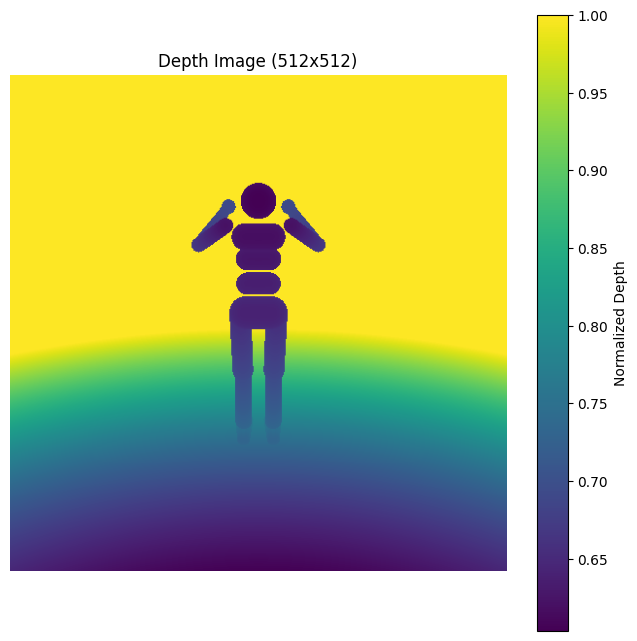

In [7]:
# Get depth data
depth_adr = rc.depth_adr.numpy()
depth_data = rc.depth_data.numpy()

start = depth_adr[cam_idx]
end = start + cam_w * cam_h
depth_row = depth_data[world_idx, start:end]

# Reshape and normalize for display
depth_image = depth_row.reshape(cam_h, cam_w)
depth_scale = 5.0  # Scale factor for visualization
depth_normalized = np.clip(depth_image / depth_scale, 0.0, 1.0)

plt.figure(figsize=(8, 8))
plt.imshow(depth_normalized, cmap="viridis")
plt.colorbar(label="Normalized Depth")
plt.title(f"Depth Image ({cam_w}x{cam_h})")
plt.axis("off")
plt.show()

## 8. Save Images to File

In [ ]:
# Save RGB image
Image.fromarray(rgb_image).save("rendered_rgb.png")
print("Saved: rendered_rgb.png")

# Save depth image
depth_uint8 = (depth_normalized * 255).astype(np.uint8)
Image.fromarray(depth_uint8).save("rendered_depth.png")
print("Saved: rendered_depth.png")

## 9. Render After Simulation Steps

You can step the simulation and re-render to see the model in different poses.

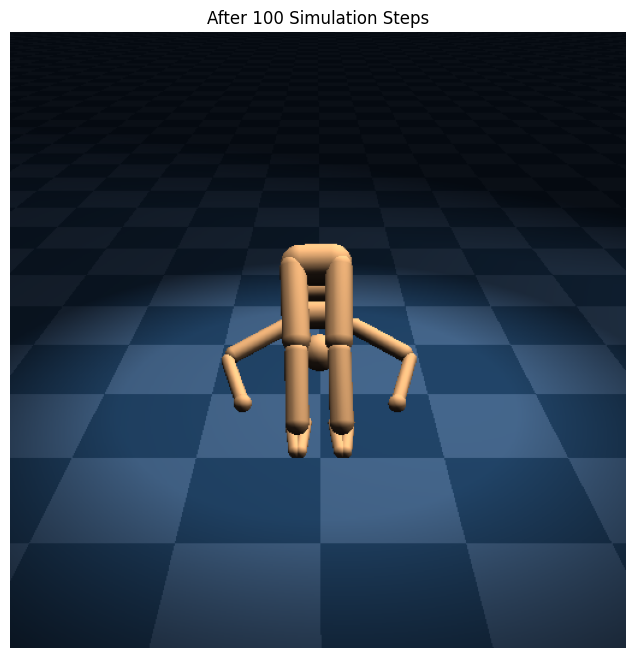

In [9]:
# Run some simulation steps
for _ in range(1000):
    mjw.step(m, d)

# Re-render
mjw.render(m, d, rc)

# Extract and display
rgb_data = rc.rgb_data.numpy()
packed_row = rgb_data[world_idx, start:end]
rgb_image = unpack_rgb(packed_row, cam_w, cam_h)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_image)
plt.title("After 100 Simulation Steps")
plt.axis("off")
plt.show()

---

## Summary: Minimal Rendering Code

Here's the absolute minimum code needed to render an image:

```python
import mujoco
import numpy as np
import warp as wp
import mujoco_warp as mjw

# 1. Load model
mjm = mujoco.MjModel.from_xml_path("model.xml")
mjd = mujoco.MjData(mjm)
mujoco.mj_forward(mjm, mjd)

# 2. Initialize GPU
wp.init()
m = mjw.put_model(mjm)
d = mjw.put_data(mjm, mjd, nworld=1)

# 3. Create render context
rc = mjw.create_render_context(
    mjm, m, d, (512, 512),
    render_rgb=True, render_depth=False,
    use_textures=True, use_shadows=False
)

# 4. Render
mjw.render(m, d, rc)

# 5. Extract image (camera 0, world 0)
rgb_adr = rc.rgb_adr.numpy()
cam_res = rc.cam_res.numpy()
w, h = int(cam_res[0][0]), int(cam_res[0][1])
packed = rc.rgb_data.numpy()[0, rgb_adr[0]:rgb_adr[0]+w*h]

# Unpack BGR -> RGB
packed = packed.reshape(h, w).astype(np.uint32)
rgb = np.dstack([
    ((packed >> 16) & 0xFF).astype(np.uint8),  # R
    ((packed >> 8) & 0xFF).astype(np.uint8),   # G
    (packed & 0xFF).astype(np.uint8),          # B
])
```